# PROGETTO 2
# 1. Data Exploration & Pre-Processing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_linnerud
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Lasso, LassoCV, LinearRegression, Ridge, RidgeCV

In [2]:
# caricamento e analisi dei dati
data = load_linnerud(as_frame=True)
X, y = data.data, data.target

display(X.describe())
display(y.describe())

,Chins,Situps,Jumps
count,20.000000,20.000000,20.00000
mean,9.450000,145.550000,70.30000
std,5.286278,62.566575,51.27747
min,1.000000,50.000000,25.00000
25%,4.750000,101.000000,39.50000
50%,11.500000,122.500000,54.00000
75%,13.250000,210.000000,85.25000
max,17.000000,251.000000,250.00000


,Weight,Waist,Pulse
count,20.000000,20.000000,20.000000
mean,178.600000,35.400000,56.100000
std,24.690505,3.201973,7.210373
min,138.000000,31.000000,46.000000
25%,160.750000,33.000000,51.500000
50%,176.000000,35.000000,55.000000
75%,191.500000,37.000000,60.500000
max,247.000000,46.000000,74.000000


In [3]:
# standardizzazione 
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

display(X_std)
print("Media:", X_std.mean().round(2))
print("Std:", X_std.std().round(2))

array([[-0.86367072,  0.26975016, -0.20608616],
       [-1.44592064, -0.58295552, -0.20608616],
       [ 0.49491243, -0.7305392 ,  0.61425681],
       [ 0.49491243, -0.66494645, -0.66627856],
       [ 0.68899574,  0.15496286, -0.24610289],
       [-1.05775403, -0.7305392 , -0.56623674],
       [-0.2814208 , -0.7305392 , -0.6462702 ],
       [-0.66958741, -0.33698273, -0.60625347],
       [ 1.07716236,  0.89288124, -0.60625347],
       [ 1.46532897,  1.72918874,  3.59550323],
       [ 1.46532897, -0.41897366, -0.6462702 ],
       [ 0.68899574,  1.0568631 ,  0.89437393],
       [ 0.88307905,  1.13885404,  0.69429027],
       [-1.64000395, -1.5668467 , -0.40616981],
       [-0.66958741, -1.23888297, -0.78632875],
       [ 0.49491243,  1.0568631 ,  0.99441575],
       [-1.05775403, -1.40286484, -0.90637895],
       [ 0.30082913,  1.38482683,  0.19408114],
       [ 1.07716236,  1.3028359 ,  0.05402259],
       [-1.44592064, -0.58295552, -0.54622837]])

Media: 0.0
Std: 1.0


# 2. Target Engineering

In [6]:
# data reduction 1D con PCA e manuale
scaler_y = StandardScaler()
y_std = scaler_y.fit_transform(y)
y_std = pd.DataFrame(y_std, columns=y.columns)

pca = PCA(n_components=1, random_state=42)
y_pca = pca.fit_transform(y_std)
print("Shape y_pca:", y_pca.shape)
display(y_pca)

y_waist = y_std[["Waist"]]
print("Shape y_waist:", y_waist.shape)
display(y_waist)


Shape y_pca: (20, 1)


array([[ 0.81780452],
       [ 0.8507056 ],
       [ 0.80612641],
       [-0.87717135],
       [ 0.79689562],
       [ 0.22012086],
       [ 1.40657367],
       [-0.82982855],
       [-2.03812801],
       [-1.14496499],
       [-0.18141258],
       [-0.58602147],
       [-1.41552003],
       [ 4.36950026],
       [ 1.10926846],
       [ 0.60350901],
       [ 0.38399813],
       [-1.0321341 ],
       [-0.97248506],
       [-2.28683639]])

Shape y_waist: (20, 1)


,Waist
0,0.192252
1,0.512673
2,0.833094
3,-0.128168
4,-0.128168
5,0.192252
6,0.833094
7,-0.448589
8,-1.409851
9,-0.769010


# 3. Addestramento e valutazione

In [21]:
# Linear, Ridge e Lasso regression per target ridotto con PCA e selezione manuale
# Memorizzazione dei risultati

results = {}

models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1)
}

targets = {
    "PCA": y_pca,
    "Manuale": y_waist
}

for model_name, model in models.items():
    for target_name, y_target in targets.items():
        
        model.fit(X_std, y_target)
        y_pred = model.predict(X_std)

        mse = mean_squared_error(y_target, y_pred)
        r2 = r2_score(y_target, y_pred)

        results[(model_name, target_name)] = {"MSE": round(mse, 4), "R2": round(r2, 4)}

        print(f"{model_name} | {target_name} --> MSE: {mse:.4f}, R2: {r2:.4f}")
              
results_df = pd.DataFrame(results).T
display(results_df)

Linear | PCA --> MSE: 1.2689, R2: 0.3970
Linear | Manuale --> MSE: 0.4522, R2: 0.5478
Ridge | PCA --> MSE: 1.2759, R2: 0.3936


Ridge | Manuale --> MSE: 0.4567, R2: 0.5433
Lasso | PCA --> MSE: 1.3324, R2: 0.3668
Lasso | Manuale --> MSE: 0.5157, R2: 0.4843


MSE      R2
Linear PCA      1.2689  0.3970
       Manuale  0.4522  0.5478
Ridge  PCA      1.2759  0.3936
       Manuale  0.4567  0.5433
Lasso  PCA      1.3324  0.3668
       Manuale  0.5157  0.4843

# 4. Analisi e visualizzazione

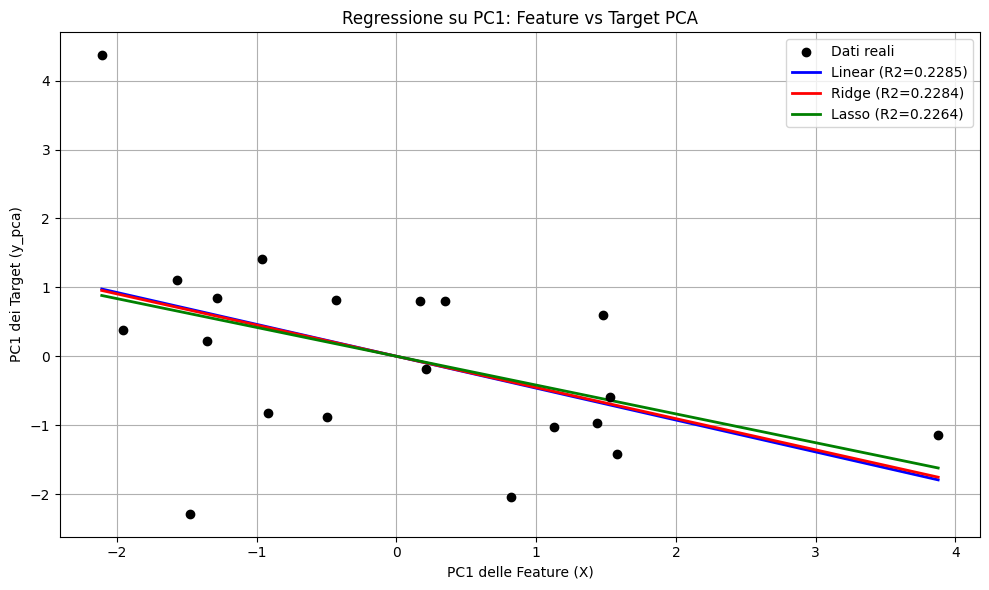

In [ ]:
# scatterplot tra y_pca e PC1 (PCA applicato alle features standardizzate) con ri-addestramento delle rette di regressione (Lineare, Ridge, Lasso)
pca_X = PCA(n_components=1, random_state=42)
X_pc1 = pca_X.fit_transform(X_std)

# riaddestramento modelli sulla PC1
models_pc1 = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1)
}

# creazione delle rette tra 2 punti min e max. 
X_line = np.array([X_pc1.min(), X_pc1.max()]).reshape(-1, 1)  # reshape trasforma l'array da 1D a 2D perchè model predict richiede inpuy 2D

# grafico
plt.figure(figsize=(10, 6))
plt.scatter(X_pc1, y_pca, color="black", zorder=5, label="Dati reali")    #zorder=punti in primo piano sul resto

colors= ["blue", "red", "green"]

for (model_name, model), color in zip(models_pc1.items(), colors):
    model.fit(X_pc1, y_pca)
    y_pred_line = model.predict(X_line)

    r2 = r2_score(y_pca, model.predict(X_pc1))   # R2 calcolato su dati reali

    plt.plot(X_line, y_pred_line, color=color, linewidth= 2, label=f"{model_name} (R2={r2:.4f})")

plt.xlabel("PC1 delle Feature (X)")
plt.ylabel("PC1 dei Target (y_pca)")
plt.title("Regressione su PC1: Feature vs Target PCA")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# il dataset Linnerud ha solo 20 osservazioni.
# con pochi dati e una sola feature la regolarizzazione non apporta benefici significativi